# Resumen

Predictor listing price y sus lags parece ser muy potente (MI superiores a 1 para lags 2,1,7, siendo 2, 1 y 7 semanas) para explicar variable objetivo suavizada a media móvil de una semana. Resto también pero en menor grado al no pasar el test de causalidad/correlación de granger. 

In [1]:
%load_ext autoreload
%autoreload 2

from temporal import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

In [2]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")

In [ ]:
columnas_temporales = ['listing_price', 'temp_mean', 'num_events']

ts_df = aggregate_daily_timeseries(df, target_col='is_occupied', continuous_cols=columnas_temporales)

[+] Agregando serie temporal a frecuencia diaria...
[+] Serie agregada creada. Dimensiones: (329, 9)

Columnas en ts_df: ['tasa_ocupacion', 'record_count', 'listing_price', 'temp_mean', 'num_events', 'tasa_ocupacion_suavizada_7d', 'listing_price_suavizada_7d', 'temp_mean_suavizada_7d', 'num_events_suavizada_7d']



📈 FUNCIÓN DE CORRELACIÓN CRUZADA (CCF)


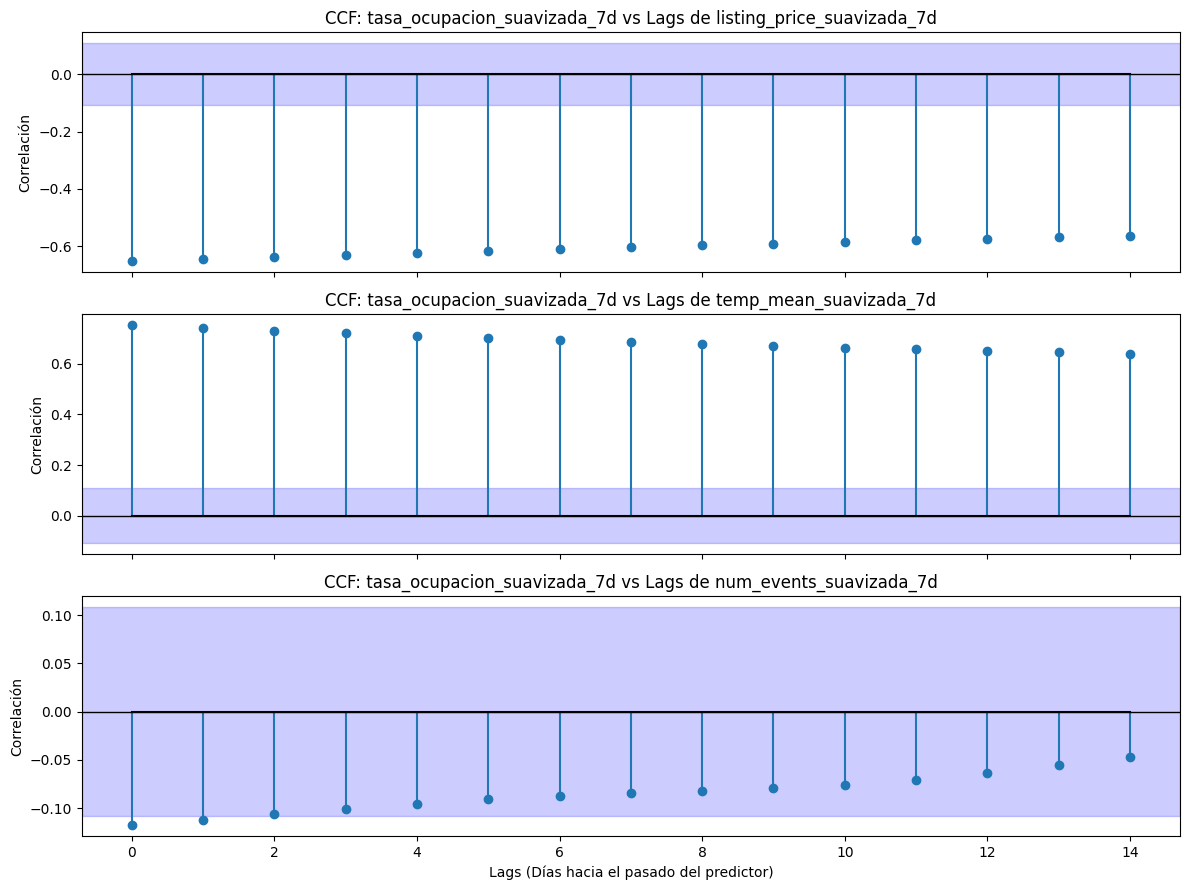


🧠 INFORMACIÓN MUTUA (MI) CON LAGS: [1, 2, 7]


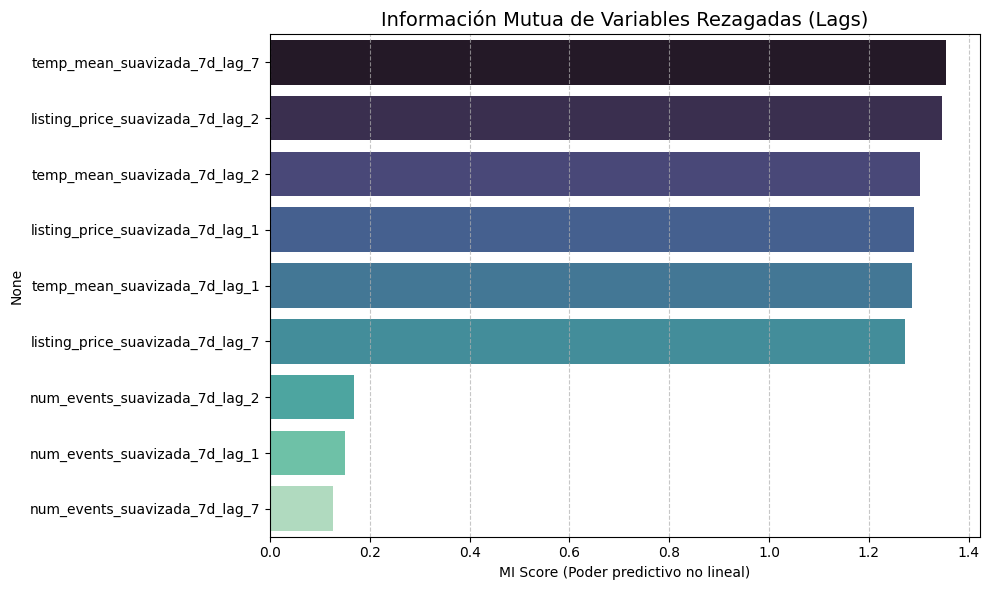

                                  MI Score
temp_mean_suavizada_7d_lag_7      1.354766
listing_price_suavizada_7d_lag_2  1.346190
temp_mean_suavizada_7d_lag_2      1.301323
listing_price_suavizada_7d_lag_1  1.290780
temp_mean_suavizada_7d_lag_1      1.285787
listing_price_suavizada_7d_lag_7  1.271765
num_events_suavizada_7d_lag_2     0.169135
num_events_suavizada_7d_lag_1     0.150078
num_events_suavizada_7d_lag_7     0.126809

🔗 TEST DE CAUSALIDAD DE GRANGER (Max Lag: 7)
H0: El predictor NO Granger-causa el target.
Regla: Si p-valor < 0.05, RECHAZAMOS H0 (Sí hay Granger-Causalidad).

--- Evaluando: listing_price_suavizada_7d -> tasa_ocupacion_suavizada_7d ---
  Lag 1: p-valor = 4.3967e-02 | Causalidad: ✅ SÍ
  Lag 2: p-valor = 6.3361e-22 | Causalidad: ✅ SÍ
  Lag 3: p-valor = 6.8546e-06 | Causalidad: ✅ SÍ
  Lag 4: p-valor = 2.5698e-07 | Causalidad: ✅ SÍ
  Lag 5: p-valor = 6.4911e-07 | Causalidad: ✅ SÍ
  Lag 6: p-valor = 1.3343e-06 | Causalidad: ✅ SÍ
  Lag 7: p-valor = 3.2836e-08 | Causal

In [ ]:
target_ts = 'tasa_ocupacion_suavizada_7d'

predictors_ts = [
    'listing_price_suavizada_7d', 
    'temp_mean_suavizada_7d',     
    'num_events_suavizada_7d'     
]

# 1. Correlación Cruzada Lineal (CCF)
plot_cross_correlation(ts_df, target=target_ts, predictors=predictors_ts, max_lags=14)

# 2. Información Mutua No Lineal
calculate_mi_with_lags(ts_df, target=target_ts, predictors=predictors_ts, lags=[1, 2, 7])

# 3. Test de Causalidad de Granger
run_granger_causality(ts_df, target=target_ts, predictors=predictors_ts, max_lag=7)